<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-DeepLearning/blob/main/DeepLearning/ex04_2_%EA%B0%9C%2C_%EA%B3%A0%EC%96%91%EC%9D%B4_%EB%B6%84%EB%A5%98_%EB%AA%A8%EB%8D%B8_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# 구글 드라이브 마운트!
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
%cd /content/drive/MyDrive/00 딥러닝

/content/drive/MyDrive/00 딥러닝


### 실습 목표
1. MLP, CNN 두 모델을 활용해서 이미지 분류 모델링 실습 -> 두 모델 성능 비교
2. 딥러닝 모델의 성능 향상 방법

In [10]:
# 필요한 라이브러리 세팅
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# 지난 시간에 전처리를 수행했던 npz 파일 불러오기
data = np.load("./data/np_cats_vs_dogs.npz")
data

NpzFile './data/np_cats_vs_dogs.npz' with keys: X_train, X_test, y_train, y_test

In [12]:
# 저장한 데이터 따로 분리해서 저장
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

In [13]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2000, 224, 224, 3), (1000, 224, 224, 3), (2000,), (1000,))

### MLP 모델링 수행
1. 신경망 구조 설계
  - Flatten
  - 중간층 3개 -> 256, 128, 64, 활성화 함수 relu
2. 학습 방법
  - adam, accuracy
3. 학습
  - 조기 학습 중단 : val_acc, 5번 참아주자
  - epochs 40, validationsplit 0.3
4. 시각화 acc, val_acc

> - InputLayer shape 어떻게 설정해야 될지(X 데이터 한 개를 받을 수 있게 설계)
> - 출력층
> - compile

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Flatten

model = Sequential()
model.add(InputLayer(shape=(224,224,3)))
model.add(Flatten())
model.add(Dense(units=256, activation="relu"))
model.add(Dense(units=128, activation="relu"))
model.add(Dense(units=64, activation="relu"))
model.add(Dense(units=1, activation="sigmoid"))

In [15]:
model.compile(
    loss="binary_crossentropy",
    optimizer="Adam",
    metrics=["accuracy"]
)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_callback = EarlyStopping(
    monitor="val_accuracy",     # monitor 기준으로 모델의 성능이 개선되었는지를 판단
    patience = 5                # 전보다 나아지지 않아도 patience만큼은 기다려 주겠다
                                # min_delta : 개선되었다고 판단할 최소한의 변화량
                                # baseline : 모니터링할 지표의 기준값 설정, 이 값보다 나아지지 않으면 바로 학습 중단
                                # restore_best_weights : 최상의 가중치를 복원할 건지 여부를 결정
)

In [17]:
h = model.fit(
    X_train, y_train,
    validation_split=0.3,
    epochs=40,
    callbacks = [early_stopping_callback]
)

Epoch 1/40


KeyboardInterrupt: 

In [ ]:
plt.plot(h.history["accuracy"], label="accuracy")
plt.plot(h.history["val_accuracy"], label="val_accuracy")
plt.legend()
plt.show()

### MLP
1. 모든 픽셀을 연산에 사용 -> 이미지의 위치에 민감 -> 다른위치에 있다면 다른 패턴으로 인식
2. 2차원 이미지 -> 1차원으로 펴주는 Flatten 사용 -> 위치 관계성 정보들을 잃게 됨

### CNN
1. 중간층을 거치기 전에 특징 부분을 추출하는 과정을 거침
-> 픽셀 위치에 비교적 덜 민감
2. 입력 > 특성 추출 > MLP(분류부)

### CNN(Convolutional Neural Network, 합성곱 신경망)
- 특징을 추출하는 데 합성곱을 사용
- 이미지나 영상 같은 시각 데이터를 처리하는 데 특화된 모델

1. Convolution Layer : 특징 추출
  - 아이디어 : 사람이 다른 사람의 얼굴을 볼 때 눈, 코, 귀 같이 부분적인 특징부터 파악하는 원리를 모방
  - 작동방식 : 필터 or 커널이라는 작은 행렬을 사용하여 이미지를 훑어가며 합성곱 연산 수행
  - 필터를 통해 이미지의 경계선, 질감 같은 국소적인 특징을 추출
  - 학습해야 할 파라미터의 수를 획기적으로 줄임

2. Pooling Layer : 압축 및 요약
  - 컨볼루션 층에서 추출된 특징 맵(이미지)의 크기를 줄여서 데이터 양을 압축, 이미지의 위치 변화에도 덜 민감하게 만듦

3. Fully Connected Layer : 최종 분류(MLP)
  - 1차원 벡터로 평탄화한 뒤 MLP 연결하여 최종적으로 대상을 분류

In [18]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D
# Conv2D : 특징을 잡아내는 역할
# MaxPooling2D : 요약

In [19]:
# CNN 모델 설계
cnn_model = Sequential()

# 입력층
cnn_model.add(InputLayer(shape=(224, 224, 3)))

# 특성 추출부
cnn_model.add(
    Conv2D(
        filters=32,        # 필터(돋보기) 개수 : 이 층을 통과하고 나면 32개의 다른 특징들을 담은 데이터로 변환
        kernel_size=(3,3), # 필터의 크기 : 데이터를 스캔할 때 사용되는 행렬의 가로세로 길이
        activation="relu", # 비선형성 변환
        padding="same",    # same : 이미지 자체가 작거나, 가장자리 정보가 중요할 때
                           # valid : 이미지 자체가 크거나, 특징들이 많을 경우
                           # 패딩 : 입출력 크기를 동일하게 하기 위해 가장자리에 숫자를 채워넣는 기능
        strides=(2,2)      # 커널의 보폭 : 양 옆, 위 아래로 2px씩 커널 이동시킴
    )
)

cnn_model.add(
    MaxPooling2D(
        pool_size=(2,2)    # 풀링 윈도우의 크기를 설정(2*2, 3*3 많이 사용)
    )
)

cnn_model.add(Conv2D(filters=64, kernel_size=(3,3), activation="relu", padding="same", strides=(2,2)))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(Conv2D(filters=64, kernel_size=(3,3), activation="relu", padding="same", strides=(2,2)))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# 1차원 변환 / 앞에서 특성 추출을 한 이후에 1차원 변환
cnn_model.add(Flatten())

cnn_model.add(Dense(256, activation="relu"))
cnn_model.add(Dense(128, activation="relu"))
cnn_model.add(Dense(64, activation="relu"))

cnn_model.add(Dense(1, activation="sigmoid"))

In [20]:
cnn_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [21]:
cnn_his = cnn_model.fit(
    X_train, y_train,
    validation_split=0.3,
    epochs=20,
    batch_size=64
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6136 - loss: 2.4930 - val_accuracy: 0.0000e+00 - val_loss: 1.5499
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 930ms/step - accuracy: 0.7171 - loss: 0.6082 - val_accuracy: 0.1683 - val_loss: 0.9391
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 928ms/step - accuracy: 0.7157 - loss: 0.5561 - val_accuracy: 0.2400 - val_loss: 0.9983
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 945ms/step - accuracy: 0.7379 - loss: 0.5404 - val_accuracy: 0.0400 - val_loss: 1.5601
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 960ms/step - accuracy: 0.7736 - loss: 0.4908 - val_accuracy: 0.3100 - val_loss: 1.1551
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 887ms/step - accuracy: 0.7993 - loss: 0.4509 - val_accuracy: 0.1467 - val_loss: 1.8069
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7950 - loss: 0.4489 - val_accuracy: 0.2133 - val_loss: 1.5201
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 906ms/step - accuracy: 0.8457 - loss: 0.3551 - val_accura

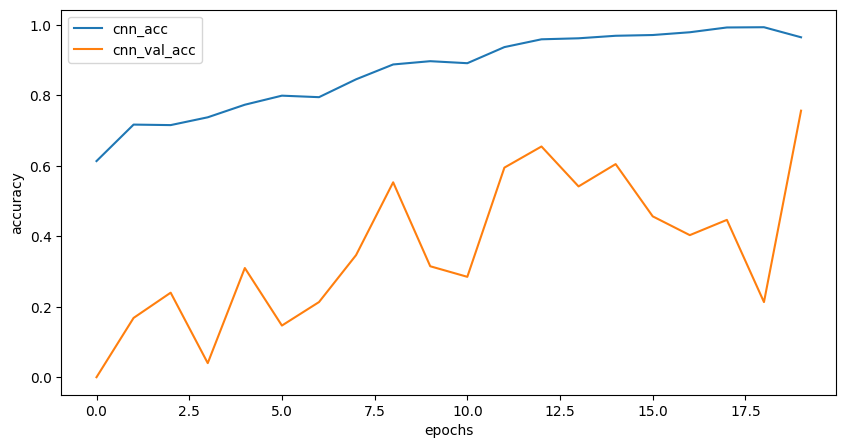

In [22]:
plt.figure(figsize=(10,5))
plt.plot(cnn_his.history["accuracy"], label="cnn_acc")
plt.plot(cnn_his.history["val_accuracy"], label="cnn_val_acc")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

# MLP보다는 좀더 성능이 확보된 것으로 확인
# -> train 데이터에서 정확도가 점점 오르고 있음
# validation 데이터에서의 정확도는 여전히 떨어짐 -> 과대적합 의심

### 딥러닝 모델의 성능을 올려보자!
1. 데이터셋을 더 늘려서 충분한 학습(좀 더 다양한 경우들을 학습)이 될 수 있도록 해보자!

> 이미지 증강(Data augmentation)
> : 이미지 회전, 이동, 확대, 축소, 뒤집기 등을 통해서 새로운 데이터가 추가된 것처럼 **train 데이터의 개수를 늘리는 방법 **

---
** Test 데이터는 증강하면 안 됨!! **


In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# 이미지 라벨링, 픽셀값 변경, 증강 등에 사용되는 도구

In [24]:
# 증강할 이미지 원본이 있는 경로 저장
train_dir = "./data/cats_and_dogs_filtered/train"
test_dir = "./data/cats_and_dogs_filtered/test"

| 옵션               | 설명                                                       |
|--------------------|------------------------------------------------------------|
| `rescale`          | 입력 이미지의 픽셀 값 재조정(ex.rescale=1.255 -> 모든 픽셀값들에 대해 0~1 사이로 정규화)|
| `rotation_range`   | 이미지의 회전 범위를 설정(ex.rotation_range -> -20~20도 사이에서 무작위로 회전)|
| `width_shift_range`| 이미지의 수평 이동 범위를 설정(ex.0.1은 전체 너비의 10%만큼 좌우로 무작위로 이동) |
| `height_shift_range`| 이미지의 수직 이동 범위를 설정(ex.0.1은 전체 너비의 10%만큼 위아래로 무작위로 이동)|
| `shear_range`      | 시계 반대 방향으로 지정된 각도만큼 변형       |
| `zoom_range`       | 이미지의 확대 및 축소 범위를 설정(ex.0.1 -> 0.9배~1.1배 사이에서 무작위로 확대하거나 축소) |
| `horizontal_flip`  | 이미지를 수평 방향으로 뒤집을지 여부를 설정       |
| `fill_mode`        | 이미지를 변형할 때 생기는 빈 공간을 채우는 방식을 설정(ex.nearest -> 가장 가까운 픽셀값을 사용하여 빈공간 채우기) |

In [25]:
# 증강기 생성 -> 학습 데이터 전용
train_gen = ImageDataGenerator(
    rescale=1./255,       # 픽셀 값을 255로 나눠서 0~1 사이의 소수로 정규화
    zoom_range=0.2,       # 0.8~1.2배 사이에서 이미지 무작위로 확대, 축소
    horizontal_flip=True  # 이미지 수평 뒤집기 허용
)

# 테스트 데이터 증강기 생성 (변형은 하지 않고, 범위만 조정) -> 정규화만 수행
test_gen = ImageDataGenerator(
    rescale=1./255
)

In [26]:
# 이미지 경로와 증강기 연결
train_generator = train_gen.flow_from_directory(
    train_dir,                 # 원본 이미지 경로
    target_size = (224, 224),  # 이미지 크기
    batch_size = 32,           # 한 번에 학습시킬 이미지의 개수
    class_mode = "binary"      # 해당 데이터의 유형 -> binary : 이진 분류
)

test_generator = test_gen.flow_from_directory(
    test_dir,
    target_size = (224, 224),
    batch_size = 32,
    class_mode = "binary"
)

# 학습시킬 때 전달해 주면 증강기가 알아서 데이터를 증강 + 나눠서 전달

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [27]:
train_generator.class_indices
# 폴더를 보고 찾아낸 데이터 라벨 확인 가능

{'cats': 0, 'dogs': 1}

### DropOut
- 학습하는 동안에 신경망의 노드들을 지정한 비율로 비활성화
- 모델이 학습 데이터를 너무 외워버리지 않도록(과대적합 방지) 학습 중에 일부 뉴런을 꺼버리는 기술

In [28]:
from tensorflow.keras.layers import Dropout

In [29]:
cnn_model2 = Sequential()

cnn_model2.add(InputLayer(shape=(224,224,3)))

cnn_model2.add(Conv2D(filters=32, kernel_size=(3,3), activation="relu", padding="same", strides=(2,2)))
cnn_model2.add(MaxPooling2D(pool_size=(2,2)))

cnn_model2.add(Dropout(0.3)) # 학습 시 30% 노드를 랜덤하게 비활성화시킴

cnn_model2.add(Conv2D(filters=64, kernel_size=(3,3), activation="relu", padding="same", strides=(2,2)))
cnn_model2.add(MaxPooling2D(pool_size=(2,2)))

cnn_model2.add(Conv2D(filters=32, kernel_size=(3,3), activation="relu", padding="same", strides=(2,2)))
cnn_model2.add(MaxPooling2D(pool_size=(2,2)))

cnn_model2.add(Dropout(0.3))

cnn_model2.add(Flatten())

cnn_model2.add(Dense(256, activation="relu"))
cnn_model2.add(Dropout(0.3))
cnn_model2.add(Dense(128, activation="relu"))
cnn_model2.add(Dense(64, activation="relu"))

cnn_model2.add(Dense(1, activation="sigmoid"))

In [30]:
cnn_model2.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [31]:
cnn2_his = cnn_model2.fit(
    train_generator,
    validation_data = test_generator,
    epochs = 20
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 786s 12s/step - accuracy: 0.4935 - loss: 0.6973 - val_accuracy: 0.5440 - val_loss: 0.6920
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5150 - loss: 0.6931 - val_accuracy: 0.4960 - val_loss: 0.6925
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5020 - loss: 0.6936 - val_accuracy: 0.5420 - val_loss: 0.6915
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5085 - loss: 0.6920 - val_accuracy: 0.5100 - val_loss: 0.6874
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5480 - loss: 0.6879 - val_accuracy: 0.5410 - val_loss: 0.6834
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5700 - loss: 0.6740 - val_accuracy: 0.6160 - val_loss: 0.6367
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5940 - loss: 0.6605 - val_accuracy: 0.5890 - val_loss: 0.6718
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.6235 - loss: 0.6474 - val_accuracy: 0.5900 - val_los

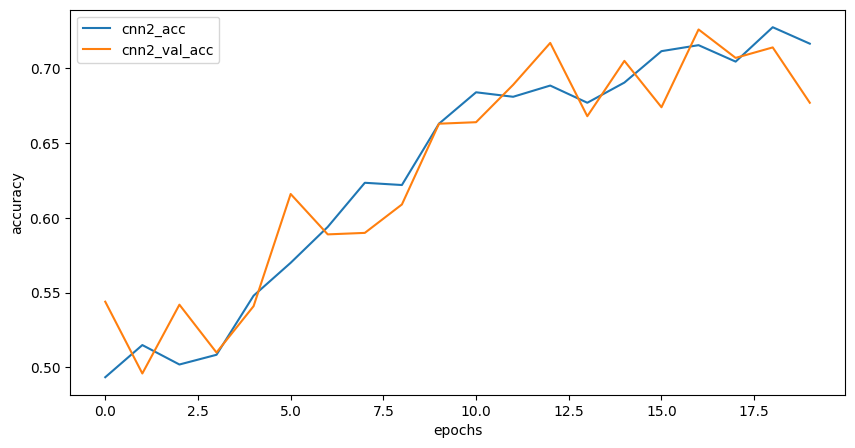

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(cnn2_his.history["accuracy"], label = "cnn2_acc")
plt.plot(cnn2_his.history["val_accuracy"], label = "cnn2_val_acc")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()